## Regression Project

Build a linear regression model that predicts the `price` column in the dataset on San Francisco Apartment rentals. Make sure to go through all the the relevant steps of the modelling workflow.

1. Data Cleaning has already been performed on this data
2. Explore the data, keeping an eye on useful features and potential issues 
3. Choose a model validation scheme (simple or cross validation)
4. Fit a Linear Regression Model
5. Evaluate your model - check assumptions, metrics, and coefficient estimates
6. Engineer Features as needed
7. Repeat Steps 2, 4, 5, 6 as needed
8. Once you are ready, fit your final model and report final model performance estimate by scoring on the test data. Report both test R-squared and MAE.

A reasonable goal is to get a validation MAE of <= 500 dollars.

Advice:

1. "Perfect" is the enemy of "Good".
2. You will not get to an MAE of 0, we don't have perfect data, and there is some randomness and emotion in how things like apartment prices are set. 
3. Modelling is challenging, especially if you're new. There isn't a "right" answer, but some models are better than others. Remember - "All Models are wrong, but some are useful" 
4. We will likely end up with different models and performance metrics, and that's ok. You can always implement new ideas after watching the solution video. I didn't do anything too fancy, so you might think of some great ideas I didn't!
5. Enjoy the process, and remember that at some point it's time to let the model go. No amount of feature engineering will achieve a perfect model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score as r2, mean_absolute_error as mae, mean_squared_error as mse
from sklearn.model_selection import train_test_split

rentals_df = pd.read_csv("Data/sf_clean.csv") 
rentals_df.head()

,price,sqft,beds,bath,laundry,pets,housing_type,parking,hood_district
0,6800,1600.0,2.0,2.0,(a) in-unit,(d) no pets,(c) multi,(b) protected,7.0
1,3500,550.0,1.0,1.0,(a) in-unit,(a) both,(c) multi,(b) protected,7.0
2,5100,1300.0,2.0,1.0,(a) in-unit,(a) both,(c) multi,(d) no parking,7.0
3,9000,3500.0,3.0,2.5,(a) in-unit,(d) no pets,(c) multi,(b) protected,7.0
4,3100,561.0,1.0,1.0,(c) no laundry,(a) both,(c) multi,(d) no parking,7.0


### Data Dictionary

1. Price: The price of the rental and our target variable
2. sqft: The area in square feet of the rental
3. beds: The number of bedrooms in the rental
4. bath: The number of bathrooms in the rental
5. laundry: Does the rental have a laundry machine inside the house, a shared laundry machine, or no laundry on site?
6. pets: Does the rental allow pets? Cats only, dogs only or both cats and dogs?
7. Housing type: Is the rental in a multi-unit building, a building with two units, or a stand alone house? 
8. Parking: Does the apartment off a parking space? No, protected in a garage, off-street in a parking lot, or valet service?
9. Hood district: Which part of San Francisco is the apartment located?

![image info](SFAR_map.png)

In [2]:
rentals_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 989 entries, 0 to 988
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          989 non-null    int64  
 1   sqft           989 non-null    float64
 2   beds           989 non-null    float64
 3   bath           989 non-null    float64
 4   laundry        989 non-null    str    
 5   pets           989 non-null    str    
 6   housing_type   989 non-null    str    
 7   parking        989 non-null    str    
 8   hood_district  989 non-null    float64
dtypes: float64(4), int64(1), str(4)
memory usage: 69.7 KB


In [3]:
rentals_df.describe()

,price,sqft,beds,bath,hood_district
count,989.000000,989.000000,989.000000,989.000000,989.000000
mean,3595.035389,976.765420,1.679474,1.390293,7.052578
std,1546.222670,474.629798,1.076710,0.562714,2.404716
min,750.000000,150.000000,0.000000,1.000000,1.000000
25%,2650.000000,650.000000,1.000000,1.000000,6.000000
50%,3300.000000,900.000000,2.000000,1.000000,8.000000
75%,4242.000000,1200.000000,2.000000,2.000000,9.000000
max,19000.000000,3500.000000,6.000000,4.000000,10.000000


## EDA


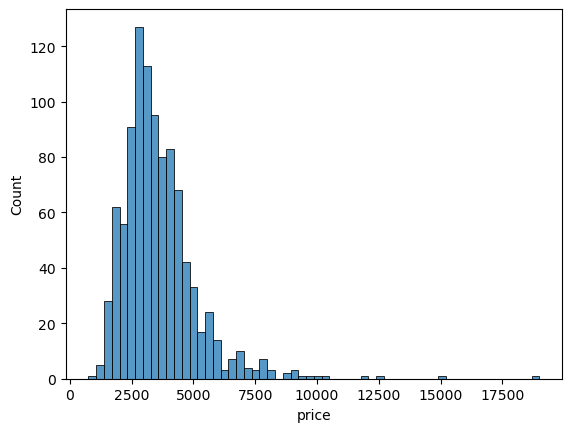

In [4]:
sns.histplot(rentals_df.price);

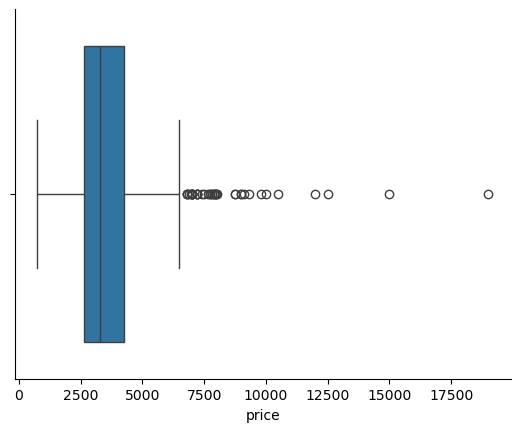

In [5]:
sns.boxplot(x=rentals_df.price);
sns.despine()

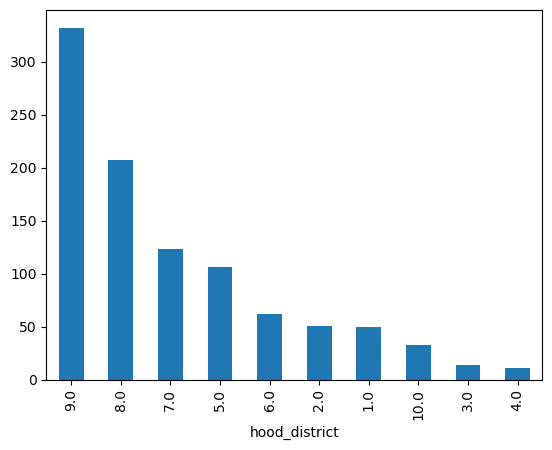

In [6]:
rentals_df.hood_district.value_counts().plot.bar();

In [7]:
rentals_df.hood_district.value_counts()

hood_district
9.0     332
8.0     207
7.0     123
5.0     106
6.0      62
2.0      51
1.0      50
10.0     33
3.0      14
4.0      11
Name: count, dtype: int64

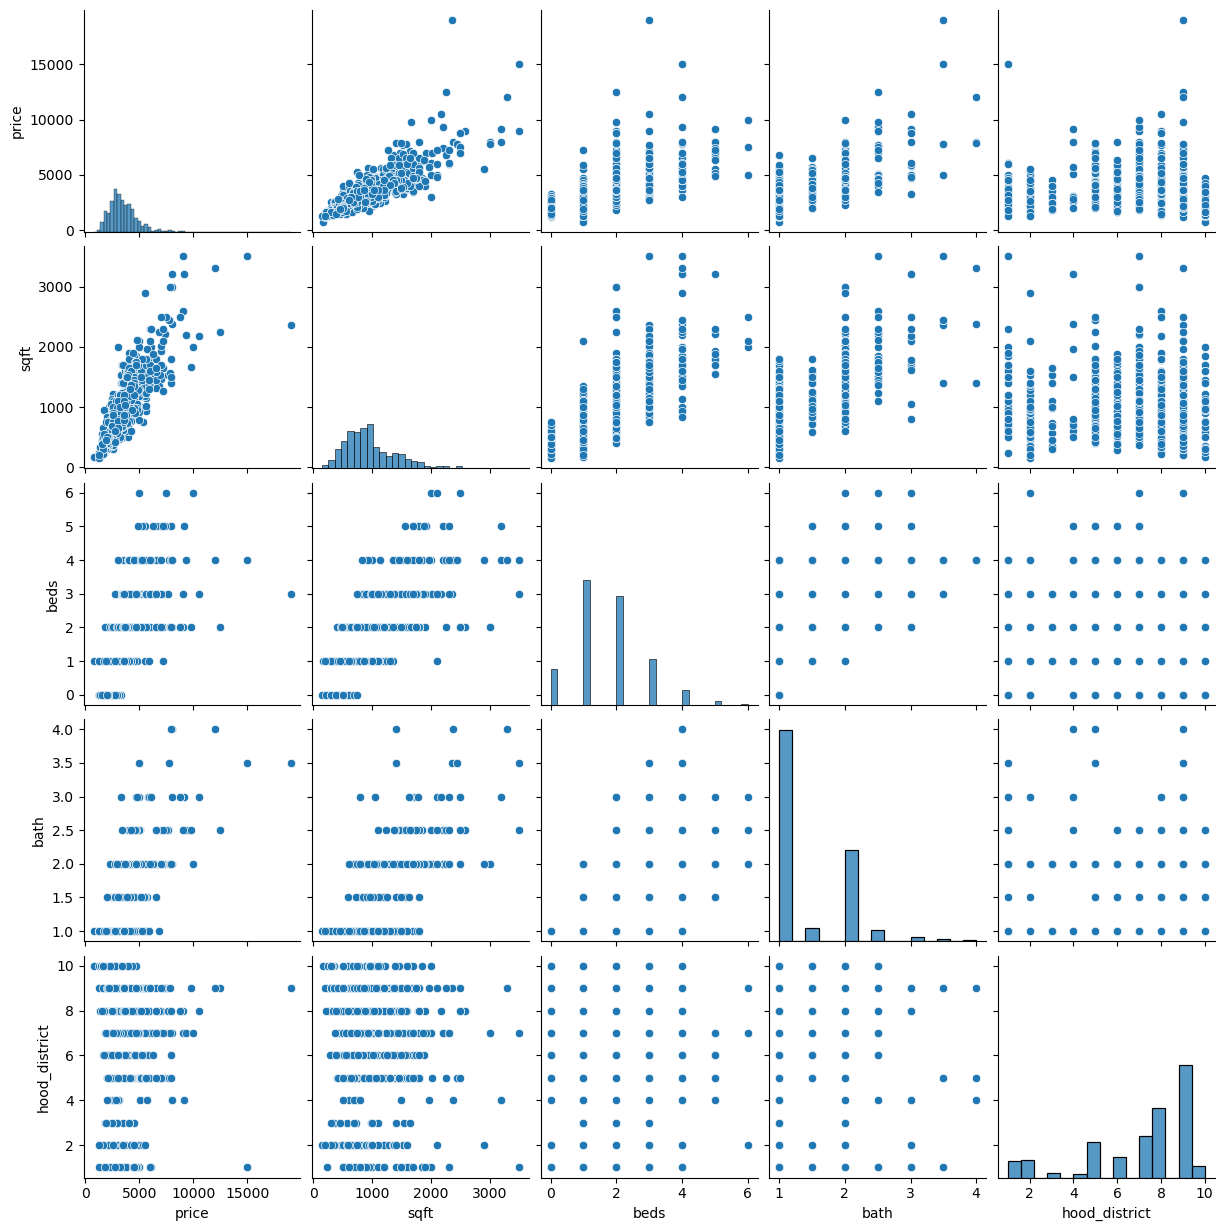

In [8]:
sns.pairplot(rentals_df);

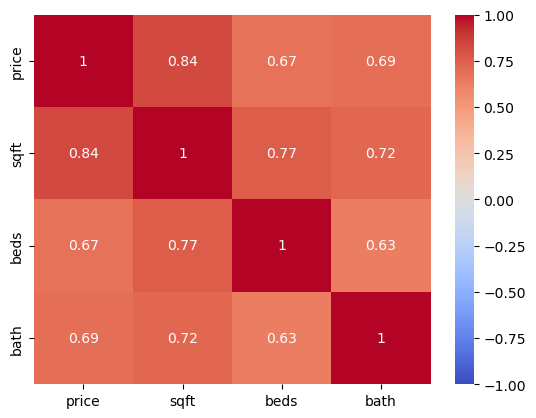

In [9]:
sns.heatmap(rentals_df[['price', 'sqft', 'beds', 'bath']].corr(), annot=True, vmin=-1, vmax=1, cmap='coolwarm');

In [10]:
rentals_df.bath.value_counts()

bath
1.0    626
2.0    269
1.5     40
2.5     33
3.0     13
3.5      5
4.0      3
Name: count, dtype: int64

In [11]:
rentals_df.beds.value_counts()

beds
1.0    370
2.0    322
3.0    134
0.0    106
4.0     43
5.0     11
6.0      3
Name: count, dtype: int64

In [12]:
rentals_df.laundry.value_counts()

laundry
(a) in-unit       488
(b) on-site       370
(c) no laundry    131
Name: count, dtype: int64

2.635783250050807


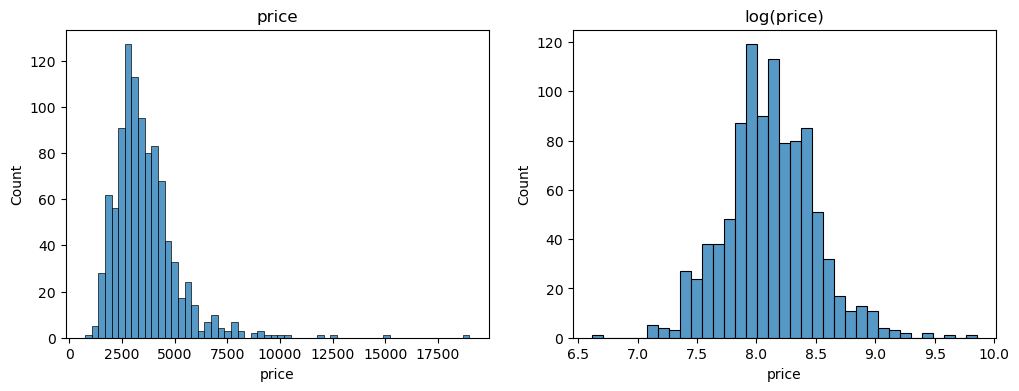

In [13]:
print(rentals_df['price'].skew())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(rentals_df['price'], ax=axes[0]).set_title('price');
sns.histplot(np.log(rentals_df['price']), ax=axes[1]).set_title('log(price)');

## EDA

The `run_eda()` function groups related plots together and can be re-run after 
feature engineering to see how transformations affect the distributions and relationships.

In [14]:
def run_eda(df):
    """
    Exploratory data analysis for the SF rentals dataset.
    Organized into 8 sections. Re-run after feature engineering to 
    compare against the original data.
    """

    numeric_cols = ['sqft', 'beds', 'bath']
    cat_cols     = ['laundry', 'pets', 'housing_type', 'parking']

    # ── 1. Target distribution ────────────────────────────────────────────────
    # Check shape, spread, and whether a log transform improves symmetry.
    # Skew > 1 generally warrants considering log(price) as the target.
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('Target Variable: Price', fontsize=13)

    sns.histplot(df['price'], ax=axes[0]).set_title('Distribution')
    sns.boxplot(x=df['price'], ax=axes[1]).set_title(f'Boxplot  (skew={df["price"].skew():.2f})')
    sns.despine(ax=axes[1])
    sns.histplot(np.log(df['price']), ax=axes[2]).set_title('log(price)')

    plt.tight_layout()
    plt.show()

    # ── 2. Numeric feature distributions ─────────────────────────────────────
    # Discrete counts for beds/bath reveal sparsity at the extremes (e.g. beds=6).
    # Sparse levels can destabilize coefficients and may need to be collapsed.
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('Numeric Feature Distributions', fontsize=13)

    for ax, col in zip(axes, numeric_cols):
        df[col].value_counts().sort_index().plot.bar(ax=ax)
        ax.set_title(col)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()

    # ── 3. Numeric features vs price ─────────────────────────────────────────
    # regplot overlays a fitted line + confidence band, giving an early read on
    # linearity. Systematic curve = consider a transform or polynomial term.
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('Numeric Features vs Price', fontsize=13)

    for ax, col in zip(axes, numeric_cols):
        sns.regplot(x=col, y='price', data=df, ax=ax, scatter_kws={'alpha': 0.3})
        ax.set_title(f'{col} vs price')

    plt.tight_layout()
    plt.show()

    # ── 4. sqft vs price by categorical hue ──────────────────────────────────
    # If slopes diverge across categories, an interaction term may improve the
    # model. Parallel slopes = additive effect only, no interaction needed.
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('sqft vs price — by Category', fontsize=13)

    for ax, hue in zip(axes.flatten(), cat_cols):
        for level in df[hue].unique():
            subset = df[df[hue] == level]
            sns.regplot(x='sqft', y='price', data=subset, ax=ax,
                        label=level,
                        scatter_kws={'alpha': 0.15},
                        line_kws={'linewidth': 2})
        ax.set_title(f'sqft vs price  |  hue: {hue}')
        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()

    # ── 4b. beds and bath vs price by categorical hue ─────────────────────────
    # All categoricals × both predictors. Let the plots tell you what interacts,
    # don't assume in advance.
    fig, axes = plt.subplots(4, 2, figsize=(14, 20))
    fig.suptitle('beds & bath vs price — by Category', fontsize=13)

    combos = [(pred, hue) for hue in cat_cols for pred in ['beds', 'bath']]

    for ax, (pred, hue) in zip(axes.flatten(), combos):
        for level in df[hue].unique():
            subset = df[df[hue] == level]
            sns.regplot(x=pred, y='price', data=subset, ax=ax,
                        label=level,
                        scatter_kws={'alpha': 0.15},
                        line_kws={'linewidth': 2})
        ax.set_title(f'{pred} vs price  |  hue: {hue}')
        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()

    # ── 5. Categorical feature distributions ─────────────────────────────────
    # Check class balance. Heavily imbalanced categories may have unreliable
    # coefficient estimates after one-hot encoding.
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle('Categorical Feature Distributions', fontsize=13)

    for ax, col in zip(axes.flatten(), cat_cols):
        df[col].value_counts().plot.bar(ax=ax)
        ax.set_title(col)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()

    # ── 6. Categorical features vs price ─────────────────────────────────────
    # Boxplots show whether price meaningfully differs across categories.
    # Overlapping boxes = weak predictor. Clear separation = useful feature.
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for ax, col in zip(axes.flatten(), cat_cols):
        df.boxplot(column='price', by=col, ax=ax)
        ax.set_title(col)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=30)

    plt.suptitle('Categorical Features vs Price', fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── 7. Hood district ──────────────────────────────────────────────────────
    # Districts 3 and 4 have very few observations — treat hood_district as 
    # categorical (not numeric) to avoid imposing a false linear ordering.
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Hood District', fontsize=13)

    df['hood_district'].value_counts().sort_index().plot.bar(ax=axes[0])
    axes[0].set_title('Count per District')

    df.boxplot(column='price', by='hood_district', ax=axes[1])
    axes[1].set_title('Price by District')

    plt.suptitle('')
    plt.tight_layout()
    plt.show()

    # ── 8. Numeric correlation matrix ────────────────────────────────────────
    # High correlation between predictors (multicollinearity) inflates standard
    # errors on OLS coefficients. beds and sqft are likely correlated — check.
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        df[['price', 'sqft', 'beds', 'bath']].corr(),
        annot=True, fmt='.2f', vmin=-1, vmax=1, cmap='coolwarm', ax=ax
    )
    ax.set_title('Numeric Correlation Matrix')
    plt.tight_layout()
    plt.show()

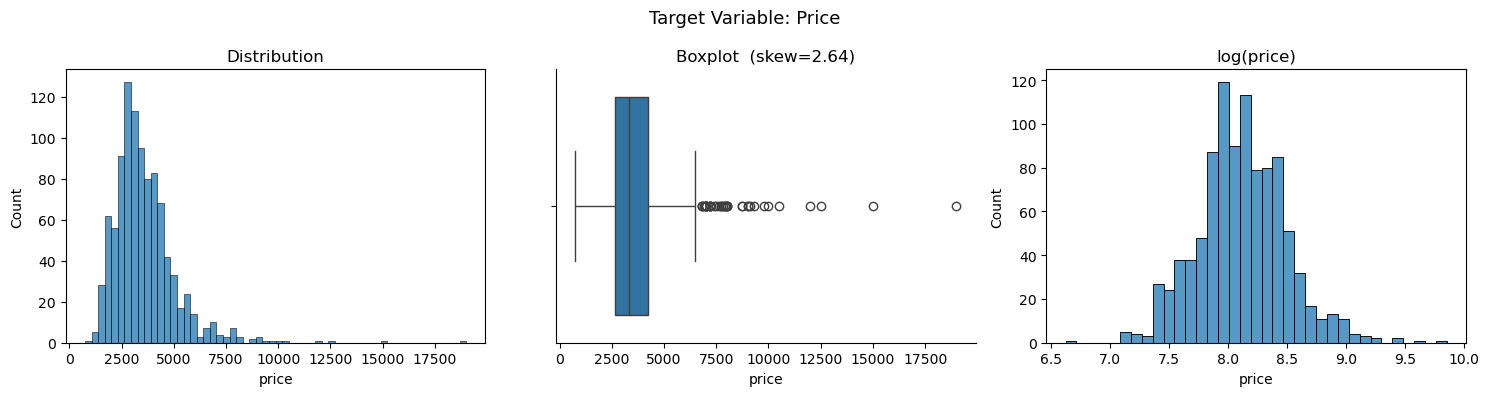

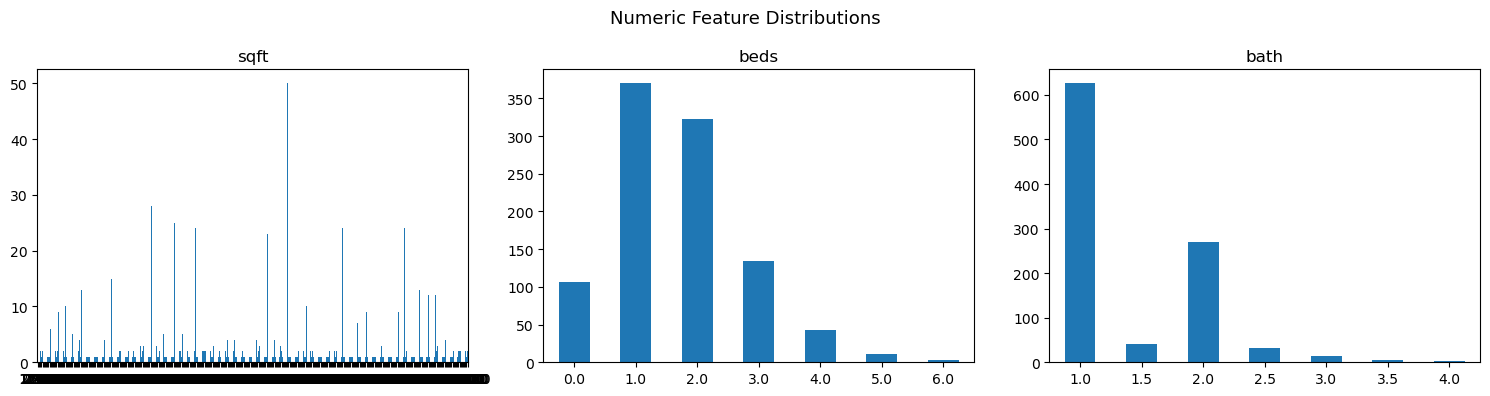

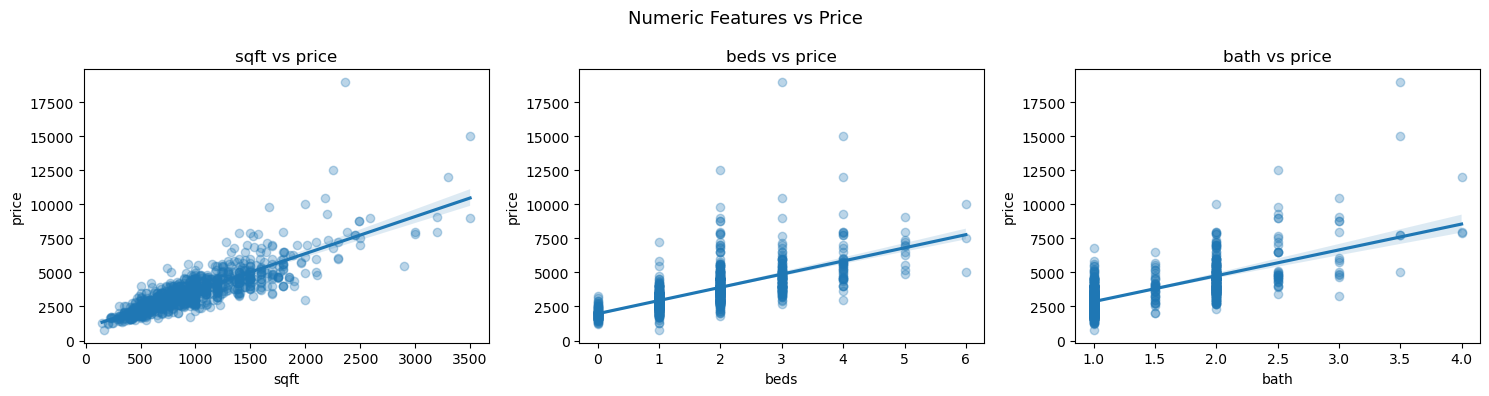

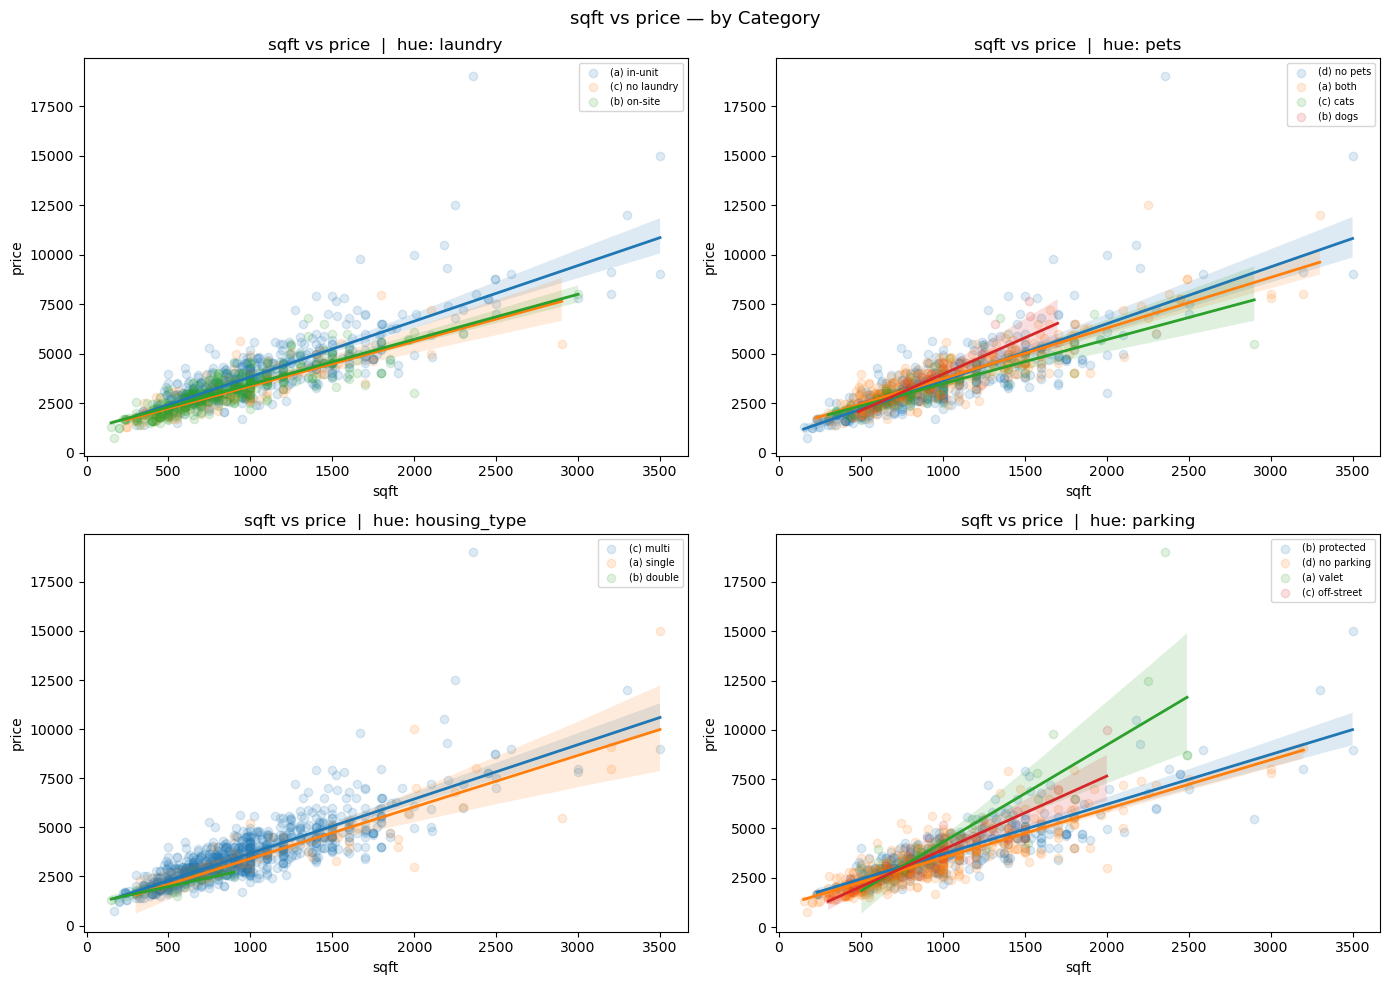

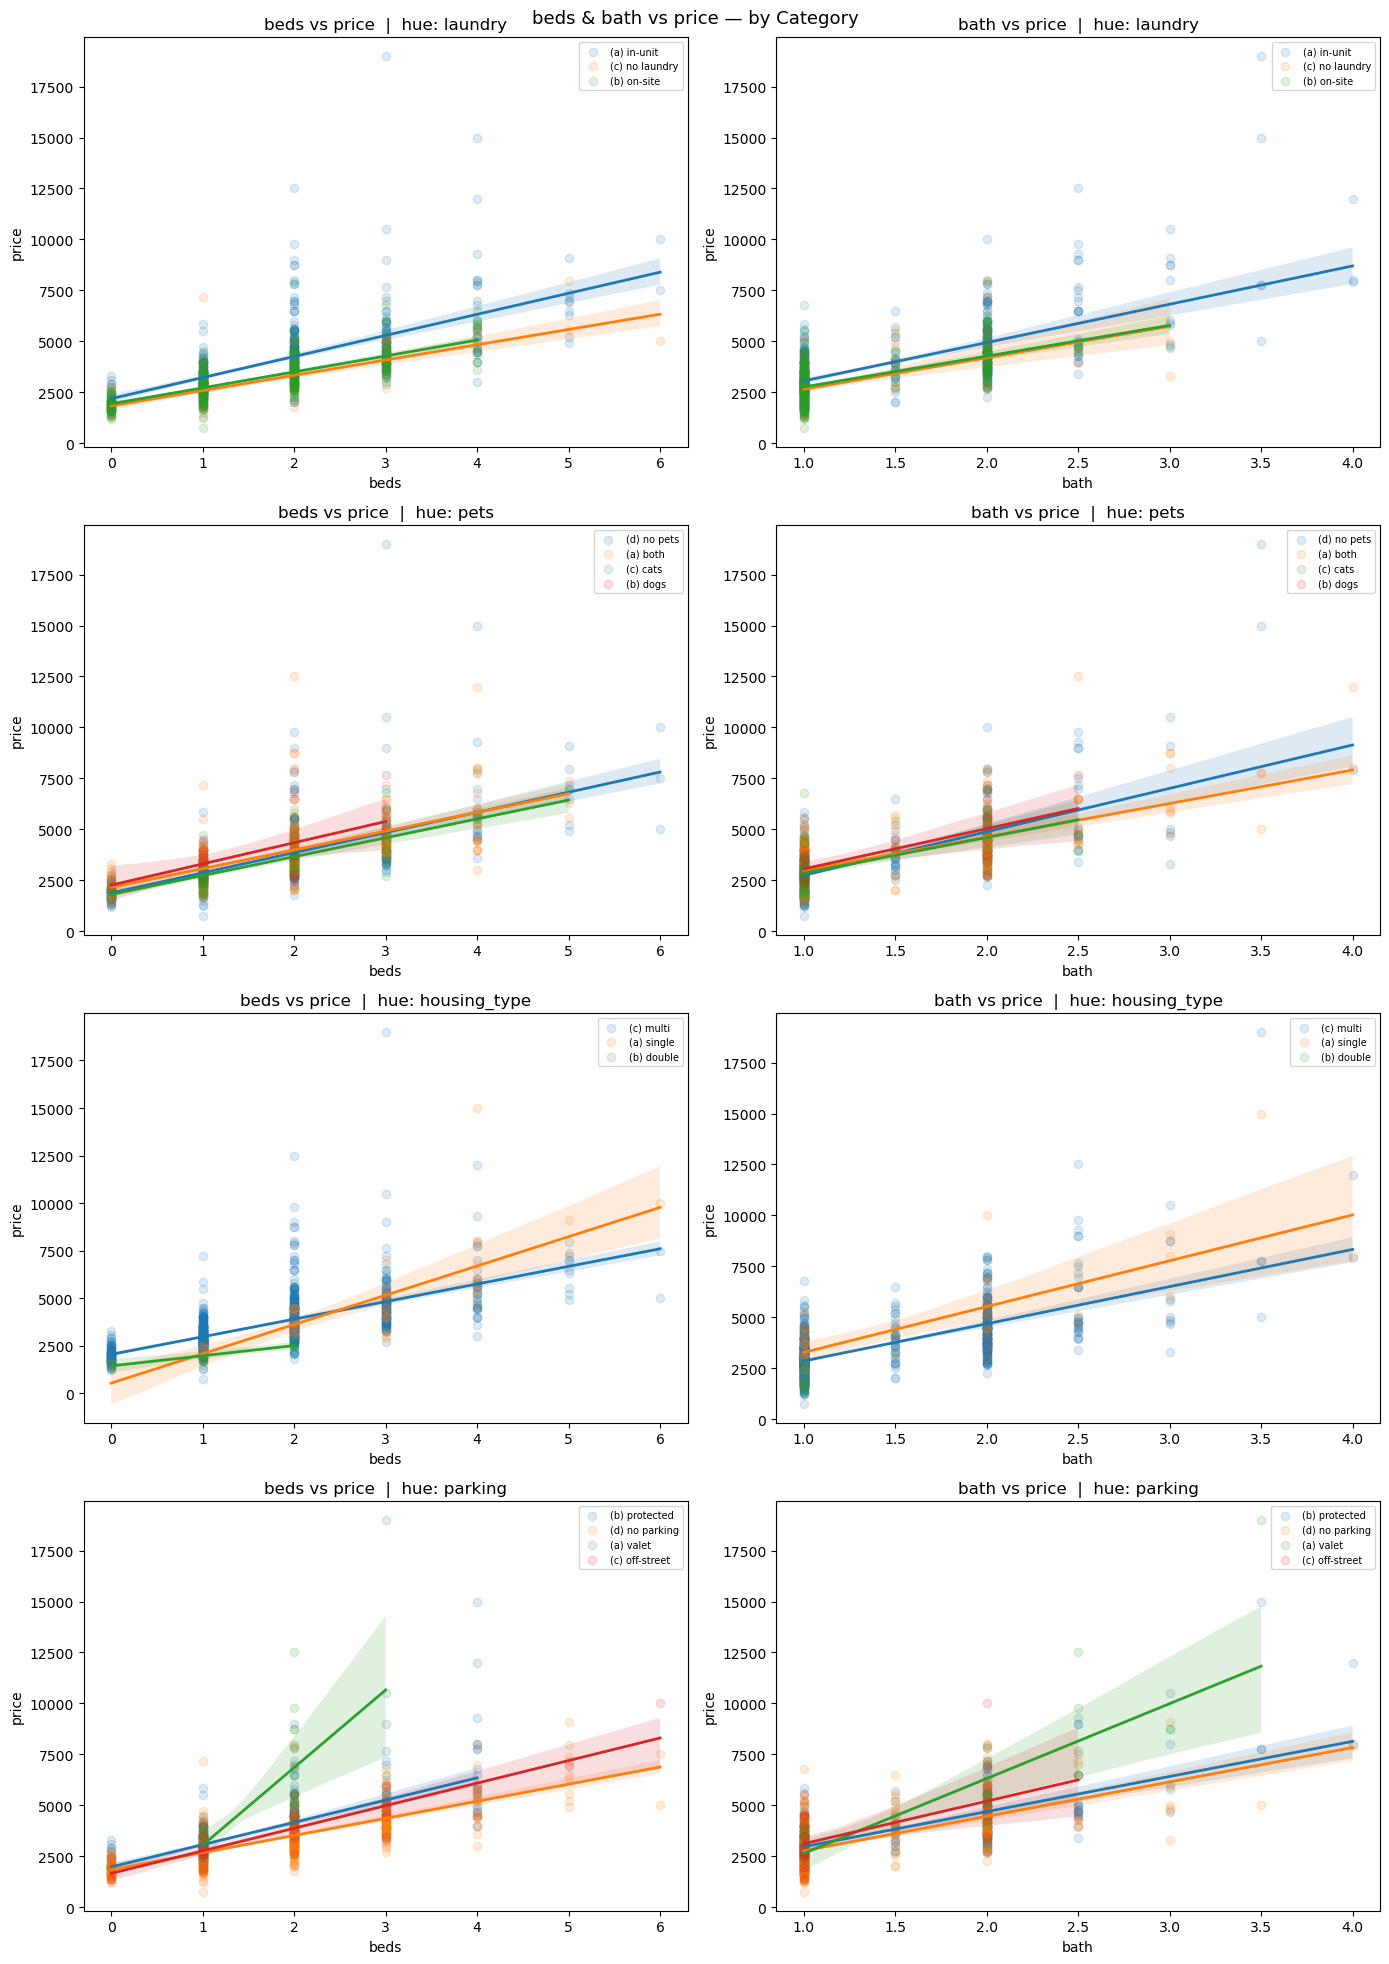

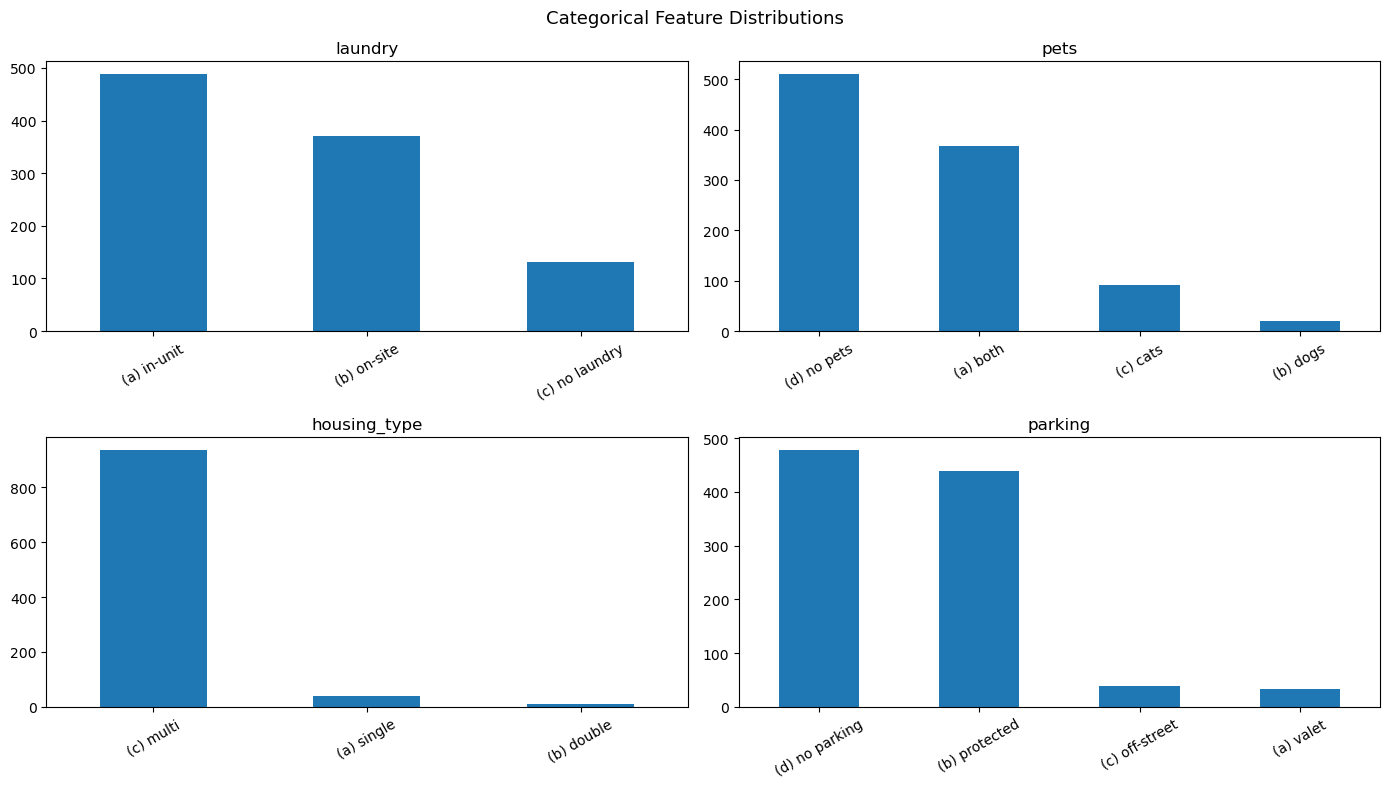

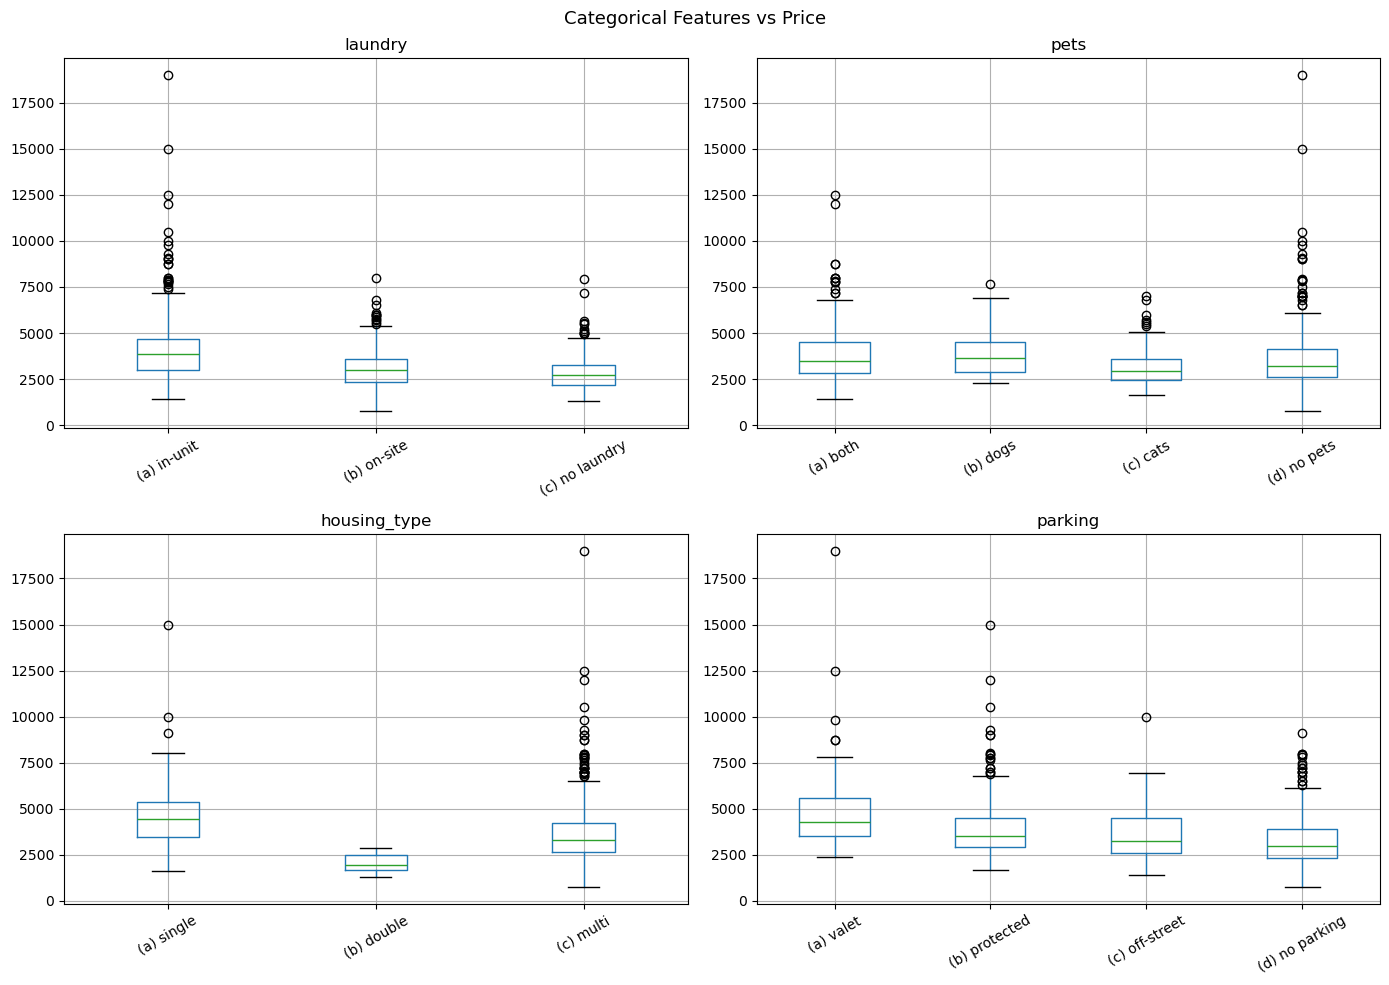

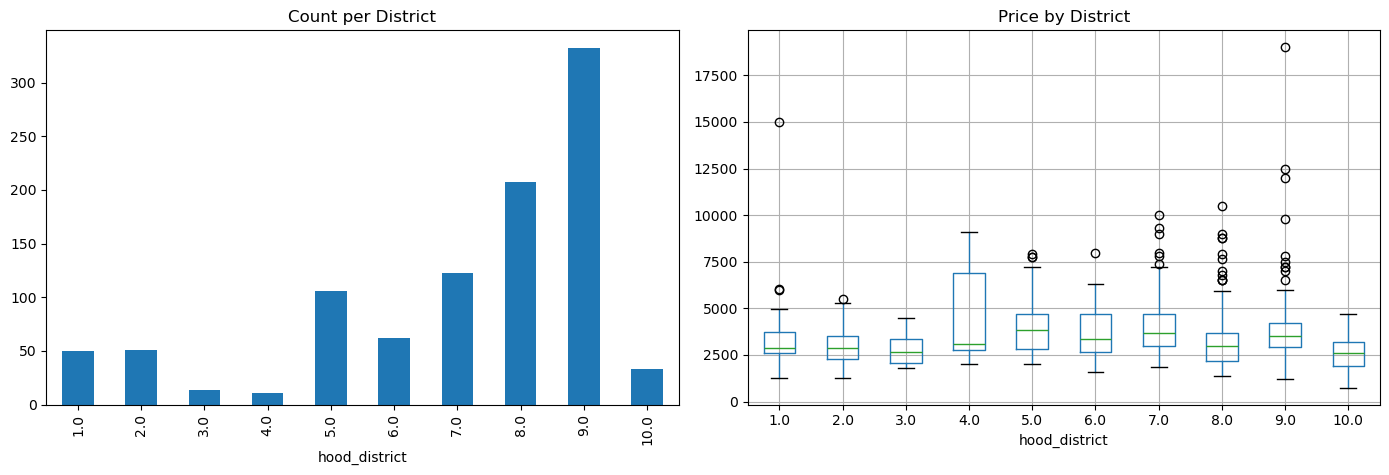

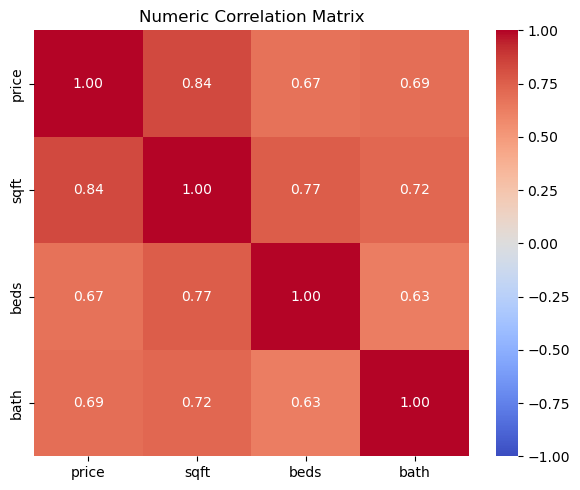

In [15]:
run_eda(rentals_df)

## Feature Engineering


In [16]:
district_map = {
    1.0: 'west',
    2.0: 'southwest',
    3.0: 'southwest',
    4.0: 'central',
    5.0: 'central',
    6.0: 'central',
    7.0: 'marina',       
    8.0: 'north_beach',  
    9.0: 'fidi_soma',    
    10.0: 'southwest',  
}

rentals_df['district_zone'] = rentals_df['hood_district'].map(district_map)

rentals_df.head()

,price,sqft,beds,bath,laundry,pets,housing_type,parking,hood_district,district_zone
0,6800,1600.0,2.0,2.0,(a) in-unit,(d) no pets,(c) multi,(b) protected,7.0,marina
1,3500,550.0,1.0,1.0,(a) in-unit,(a) both,(c) multi,(b) protected,7.0,marina
2,5100,1300.0,2.0,1.0,(a) in-unit,(a) both,(c) multi,(d) no parking,7.0,marina
3,9000,3500.0,3.0,2.5,(a) in-unit,(d) no pets,(c) multi,(b) protected,7.0,marina
4,3100,561.0,1.0,1.0,(c) no laundry,(a) both,(c) multi,(d) no parking,7.0,marina


In [17]:
# Collapse the three parallel categories — their slopes are identical
# across sqft, beds, and bath in every plot
rentals_df['is_valet'] = (rentals_df['parking'] == '(a) valet').astype(int)
rentals_df['valet_x_sqft'] = rentals_df['is_valet'] * rentals_df['sqft']
rentals_df['valet_x_beds'] = rentals_df['is_valet'] * rentals_df['beds']
rentals_df['valet_x_bath'] = rentals_df['is_valet'] * rentals_df['bath']

rentals_df['has_parking']   = (rentals_df['parking'] != '(d) no parking').astype(int)

rentals_df.head()

,price,sqft,beds,bath,laundry,pets,housing_type,parking,hood_district,district_zone,is_valet,valet_x_sqft,valet_x_beds,valet_x_bath,has_parking
0,6800,1600.0,2.0,2.0,(a) in-unit,(d) no pets,(c) multi,(b) protected,7.0,marina,0,0.0,0.0,0.0,1
1,3500,550.0,1.0,1.0,(a) in-unit,(a) both,(c) multi,(b) protected,7.0,marina,0,0.0,0.0,0.0,1
2,5100,1300.0,2.0,1.0,(a) in-unit,(a) both,(c) multi,(d) no parking,7.0,marina,0,0.0,0.0,0.0,0
3,9000,3500.0,3.0,2.5,(a) in-unit,(d) no pets,(c) multi,(b) protected,7.0,marina,0,0.0,0.0,0.0,1
4,3100,561.0,1.0,1.0,(c) no laundry,(a) both,(c) multi,(d) no parking,7.0,marina,0,0.0,0.0,0.0,0


In [18]:
laundry_map = {
    '(a) in-unit':    'in_unit',
    '(b) on-site':    'not_in_unit',
    '(c) no laundry': 'not_in_unit',
}

rentals_df['laundry'] = rentals_df['laundry'].map(laundry_map)
rentals_df.head()

,price,sqft,beds,bath,laundry,pets,housing_type,parking,hood_district,district_zone,is_valet,valet_x_sqft,valet_x_beds,valet_x_bath,has_parking
0,6800,1600.0,2.0,2.0,in_unit,(d) no pets,(c) multi,(b) protected,7.0,marina,0,0.0,0.0,0.0,1
1,3500,550.0,1.0,1.0,in_unit,(a) both,(c) multi,(b) protected,7.0,marina,0,0.0,0.0,0.0,1
2,5100,1300.0,2.0,1.0,in_unit,(a) both,(c) multi,(d) no parking,7.0,marina,0,0.0,0.0,0.0,0
3,9000,3500.0,3.0,2.5,in_unit,(d) no pets,(c) multi,(b) protected,7.0,marina,0,0.0,0.0,0.0,1
4,3100,561.0,1.0,1.0,not_in_unit,(a) both,(c) multi,(d) no parking,7.0,marina,0,0.0,0.0,0.0,0


In [19]:
# Single family homes price-per-bedroom/bathroom differently than multi-unit
rentals_df['is_single'] = (rentals_df['housing_type'] == '(a) single').astype(int)

rentals_df['single_x_beds'] = rentals_df['is_single'] * rentals_df['beds']
rentals_df['single_x_bath'] = rentals_df['is_single'] * rentals_df['bath']

rentals_df.head()

,price,sqft,beds,bath,laundry,pets,housing_type,parking,hood_district,district_zone,is_valet,valet_x_sqft,valet_x_beds,valet_x_bath,has_parking,is_single,single_x_beds,single_x_bath
0,6800,1600.0,2.0,2.0,in_unit,(d) no pets,(c) multi,(b) protected,7.0,marina,0,0.0,0.0,0.0,1,0,0.0,0.0
1,3500,550.0,1.0,1.0,in_unit,(a) both,(c) multi,(b) protected,7.0,marina,0,0.0,0.0,0.0,1,0,0.0,0.0
2,5100,1300.0,2.0,1.0,in_unit,(a) both,(c) multi,(d) no parking,7.0,marina,0,0.0,0.0,0.0,0,0,0.0,0.0
3,9000,3500.0,3.0,2.5,in_unit,(d) no pets,(c) multi,(b) protected,7.0,marina,0,0.0,0.0,0.0,1,0,0.0,0.0
4,3100,561.0,1.0,1.0,not_in_unit,(a) both,(c) multi,(d) no parking,7.0,marina,0,0.0,0.0,0.0,0,0,0.0,0.0


In [20]:
pet_map = {
    '(a) both': 'allows_dogs',
    '(b) dogs': 'allows_dogs',
    '(c) cats': 'no_dogs',
    '(d) no pets': 'no_dogs',
}

rentals_df['pets'] = rentals_df['pets'].map(pet_map)

rentals_df.head()

,price,sqft,beds,bath,laundry,pets,housing_type,parking,hood_district,district_zone,is_valet,valet_x_sqft,valet_x_beds,valet_x_bath,has_parking,is_single,single_x_beds,single_x_bath
0,6800,1600.0,2.0,2.0,in_unit,no_dogs,(c) multi,(b) protected,7.0,marina,0,0.0,0.0,0.0,1,0,0.0,0.0
1,3500,550.0,1.0,1.0,in_unit,allows_dogs,(c) multi,(b) protected,7.0,marina,0,0.0,0.0,0.0,1,0,0.0,0.0
2,5100,1300.0,2.0,1.0,in_unit,allows_dogs,(c) multi,(d) no parking,7.0,marina,0,0.0,0.0,0.0,0,0,0.0,0.0
3,9000,3500.0,3.0,2.5,in_unit,no_dogs,(c) multi,(b) protected,7.0,marina,0,0.0,0.0,0.0,1,0,0.0,0.0
4,3100,561.0,1.0,1.0,not_in_unit,allows_dogs,(c) multi,(d) no parking,7.0,marina,0,0.0,0.0,0.0,0,0,0.0,0.0


In [21]:
housing_map = {
    '(a) single': 'single',
    '(b) double': 'multi',
    '(c) multi':  'multi',
}

rentals_df['housing_type'] = rentals_df['housing_type'].map(housing_map)

rentals_df.head()

,price,sqft,beds,bath,laundry,pets,housing_type,parking,hood_district,district_zone,is_valet,valet_x_sqft,valet_x_beds,valet_x_bath,has_parking,is_single,single_x_beds,single_x_bath
0,6800,1600.0,2.0,2.0,in_unit,no_dogs,multi,(b) protected,7.0,marina,0,0.0,0.0,0.0,1,0,0.0,0.0
1,3500,550.0,1.0,1.0,in_unit,allows_dogs,multi,(b) protected,7.0,marina,0,0.0,0.0,0.0,1,0,0.0,0.0
2,5100,1300.0,2.0,1.0,in_unit,allows_dogs,multi,(d) no parking,7.0,marina,0,0.0,0.0,0.0,0,0,0.0,0.0
3,9000,3500.0,3.0,2.5,in_unit,no_dogs,multi,(b) protected,7.0,marina,0,0.0,0.0,0.0,1,0,0.0,0.0
4,3100,561.0,1.0,1.0,not_in_unit,allows_dogs,multi,(d) no parking,7.0,marina,0,0.0,0.0,0.0,0,0,0.0,0.0


In [22]:
rentals_df.drop(columns=['hood_district'], inplace = True)
rentals_df.head()

,price,sqft,beds,bath,laundry,pets,housing_type,parking,district_zone,is_valet,valet_x_sqft,valet_x_beds,valet_x_bath,has_parking,is_single,single_x_beds,single_x_bath
0,6800,1600.0,2.0,2.0,in_unit,no_dogs,multi,(b) protected,marina,0,0.0,0.0,0.0,1,0,0.0,0.0
1,3500,550.0,1.0,1.0,in_unit,allows_dogs,multi,(b) protected,marina,0,0.0,0.0,0.0,1,0,0.0,0.0
2,5100,1300.0,2.0,1.0,in_unit,allows_dogs,multi,(d) no parking,marina,0,0.0,0.0,0.0,0,0,0.0,0.0
3,9000,3500.0,3.0,2.5,in_unit,no_dogs,multi,(b) protected,marina,0,0.0,0.0,0.0,1,0,0.0,0.0
4,3100,561.0,1.0,1.0,not_in_unit,allows_dogs,multi,(d) no parking,marina,0,0.0,0.0,0.0,0,0,0.0,0.0


In [23]:
rentals_df = pd.get_dummies(rentals_df, drop_first=True, dtype=int)
rentals_df.head()

,price,sqft,beds,bath,is_valet,valet_x_sqft,valet_x_beds,valet_x_bath,has_parking,is_single,...,pets_no_dogs,housing_type_single,parking_(b) protected,parking_(c) off-street,parking_(d) no parking,district_zone_fidi_soma,district_zone_marina,district_zone_north_beach,district_zone_southwest,district_zone_west
0,6800,1600.0,2.0,2.0,0,0.0,0.0,0.0,1,0,...,1,0,1,0,0,0,1,0,0,0
1,3500,550.0,1.0,1.0,0,0.0,0.0,0.0,1,0,...,0,0,1,0,0,0,1,0,0,0
2,5100,1300.0,2.0,1.0,0,0.0,0.0,0.0,0,0,...,0,0,0,0,1,0,1,0,0,0
3,9000,3500.0,3.0,2.5,0,0.0,0.0,0.0,1,0,...,1,0,1,0,0,0,1,0,0,0
4,3100,561.0,1.0,1.0,0,0.0,0.0,0.0,0,0,...,0,0,0,0,1,0,1,0,0,0


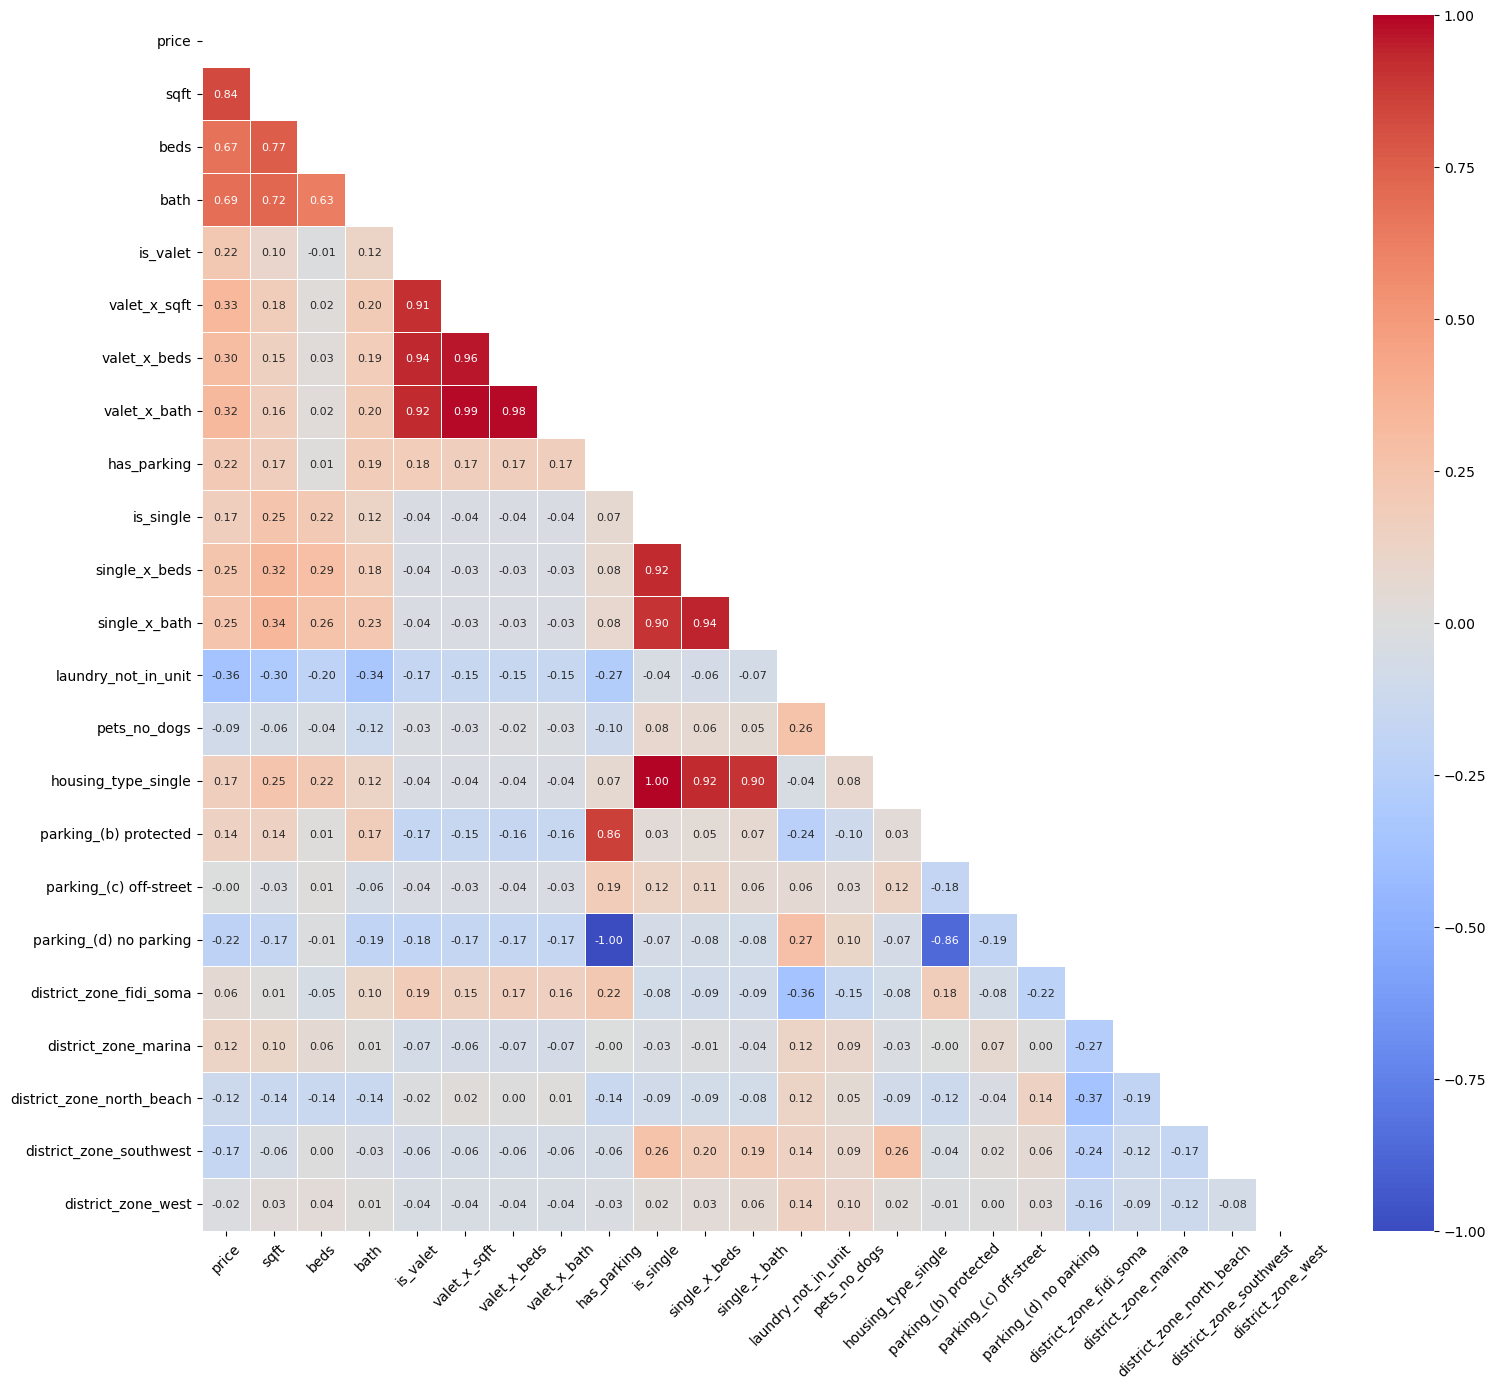

In [24]:
fig, ax = plt.subplots(figsize=(16, 14))

mask = np.triu(np.ones_like(rentals_df.corr(), dtype=bool))  # hide upper triangle — it's redundant

sns.heatmap(
    rentals_df.corr(),
    annot=True, fmt='.2f',
    vmin=-1, vmax=1, cmap='coolwarm',
    mask=mask,
    annot_kws={'size': 8},
    linewidths=0.5,
    ax=ax
);
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

## Data Splitting

In [25]:
X = rentals_df.drop(columns=['price'])
y = np.log(rentals_df['price'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Fitting & Validation Scoring

In [26]:
results = {}

def cv_evaluate(X_train, y_train, features, label):
    kf = KFold(n_splits=5, shuffle=True, random_state=2023)
    val_r2s, val_maes = [], []

    for tr_idx, val_idx in kf.split(X_train, y_train):
        Xtr = sm.add_constant(X_train[features].iloc[tr_idx])
        ytr = y_train.iloc[tr_idx]
        Xv  = sm.add_constant(X_train[features].iloc[val_idx])
        yv  = y_train.iloc[val_idx]
        m   = sm.OLS(ytr, Xtr).fit()
        preds = m.predict(Xv)
        val_r2s.append(r2(yv, preds))
        val_maes.append(mae(np.exp(yv), np.exp(preds)))

    full_model = sm.OLS(y_train, sm.add_constant(X_train[features])).fit()

    results[label] = {
        'label':       label,
        'features':    features,
        'n_features':  len(features),
        'cv_r2_mean':  round(np.mean(val_r2s), 3),
        'cv_r2_std':   round(np.std(val_r2s),  3),
        'cv_mae_mean': round(np.mean(val_maes), 1),
        'cv_mae_std':  round(np.std(val_maes),  1),
    }

    print(f"CV R2:  {np.mean(val_r2s):.3f} +- {np.std(val_r2s):.3f}")
    print(f"CV MAE: {np.mean(val_maes):.1f} +- {np.std(val_maes):.1f}")

    return full_model



In [27]:
def show_results():
    return pd.DataFrame(results.values()).sort_values('cv_mae_mean')

In [28]:
def score_final_model(X_train, y_train, X_test, y_test, label):
    features = results[label]['features']          # direct dict lookup, no fragile next()

    Xt  = sm.add_constant(X_train[features])
    Xte = sm.add_constant(X_test[features])

    final_model = sm.OLS(y_train, Xt).fit()
    preds = final_model.predict(Xte)

    print(f"Test R2:  {r2(y_test, preds):.3f}")
    print(f"Test MAE: {mae(np.exp(y_test), np.exp(preds)):.1f}")

    return final_model

In [29]:
def residual_analysis_plots(model):
    
    import scipy.stats as stats
    import matplotlib.pyplot as plt
    
    predictions = model.predict()
    residuals = model.resid
    
    fig, ax = plt.subplots(1, 2, sharey="all", figsize=(10, 6))
    
    sns.scatterplot(x=predictions, y=residuals, ax=ax[0], alpha=.3)
    ax[0].set_title("Residual Plot")
    ax[0].set_xlabel("Prediction")
    ax[0].set_ylabel("Residuals")
    
    stats.probplot(residuals, dist="norm", plot=ax[1])
    ax[1].set_title("Normal Q-Q Plot")   


In [30]:
rentals_df.columns

Index(['price', 'sqft', 'beds', 'bath', 'is_valet', 'valet_x_sqft',
       'valet_x_beds', 'valet_x_bath', 'has_parking', 'is_single',
       'single_x_beds', 'single_x_bath', 'laundry_not_in_unit', 'pets_no_dogs',
       'housing_type_single', 'parking_(b) protected',
       'parking_(c) off-street', 'parking_(d) no parking',
       'district_zone_fidi_soma', 'district_zone_marina',
       'district_zone_north_beach', 'district_zone_southwest',
       'district_zone_west'],
      dtype='str')

CV R2:  0.737 +- 0.040
CV MAE: 559.9 +- 52.7
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.745
Model:                            OLS   Adj. R-squared:                  0.744
Method:                 Least Squares   F-statistic:                     766.3
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          6.01e-233
Time:                        11:31:08   Log-Likelihood:                 186.65
No. Observations:                 791   AIC:                            -365.3
Df Residuals:                     787   BIC:                            -346.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const  

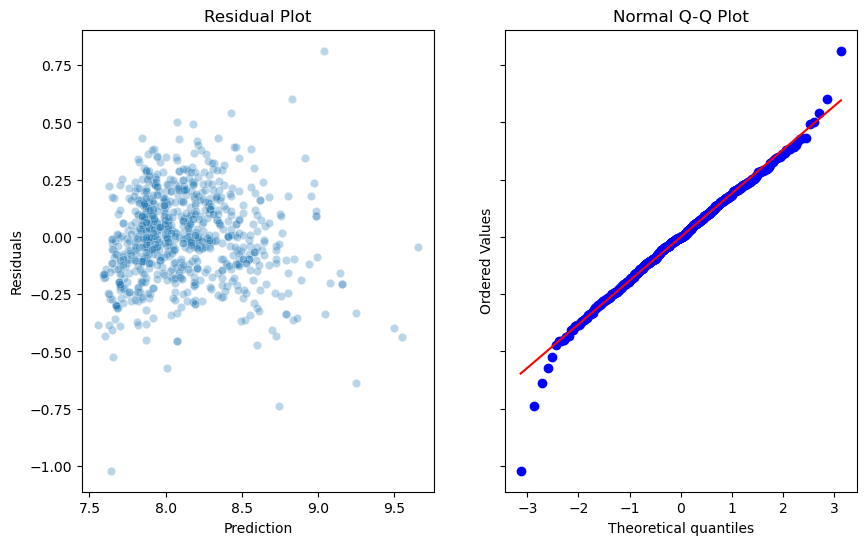

In [31]:
features = ['sqft', 'beds', 'bath']
m1 = cv_evaluate(X_train, y_train, features, 'M1_baseline')
print(m1.summary())
residual_analysis_plots(m1)

CV R2:  0.754 +- 0.038
CV MAE: 543.3 +- 48.9
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.762
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     628.2
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          4.62e-243
Time:                        11:31:08   Log-Likelihood:                 213.53
No. Observations:                 791   AIC:                            -417.1
Df Residuals:                     786   BIC:                            -393.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

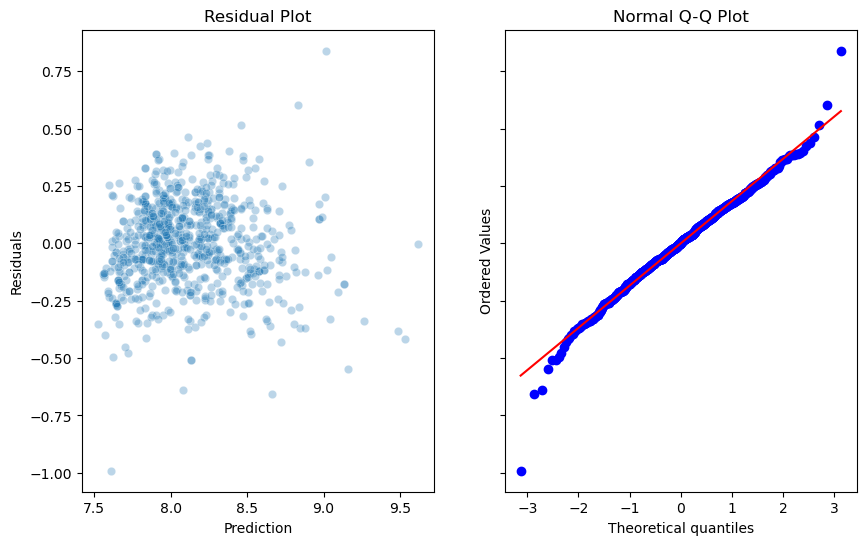

In [32]:
features = ['sqft', 'beds', 'bath', 'laundry_not_in_unit']
m2 = cv_evaluate(X_train, y_train, features, 'M2_laundry')
print(m2.summary())
residual_analysis_plots(m2)

CV R2:  0.770 +- 0.035
CV MAE: 513.5 +- 45.8
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.780
Model:                            OLS   Adj. R-squared:                  0.778
Method:                 Least Squares   F-statistic:                     396.8
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          1.56e-252
Time:                        11:31:08   Log-Likelihood:                 245.22
No. Observations:                 791   AIC:                            -474.4
Df Residuals:                     783   BIC:                            -437.1
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

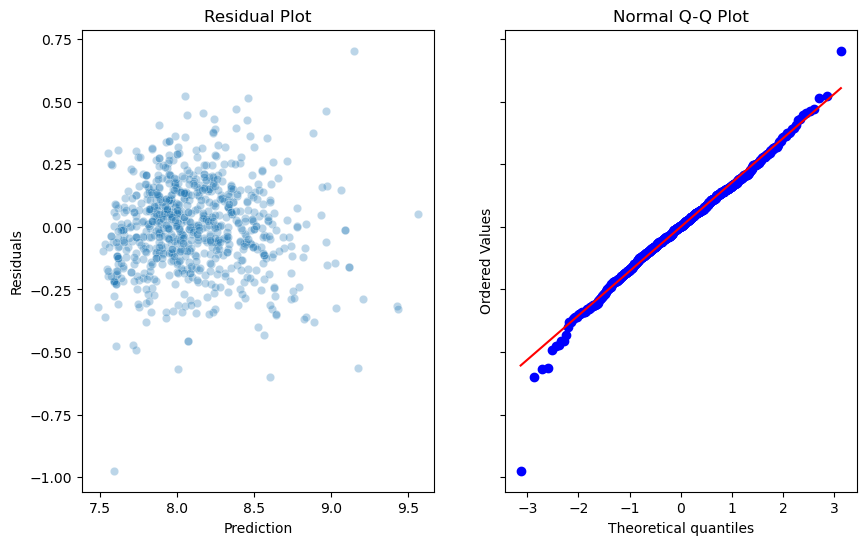

In [33]:
features = ['sqft', 'beds', 'bath', 'laundry_not_in_unit', 'parking_(b) protected','parking_(c) off-street', 'parking_(d) no parking']
m3 = cv_evaluate(X_train, y_train, features,'M3_parking')
print(m3.summary())
residual_analysis_plots(m3)

CV R2:  0.798 +- 0.030
CV MAE: 490.3 +- 45.3
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.810
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     276.9
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          4.28e-271
Time:                        11:31:08   Log-Likelihood:                 303.62
No. Observations:                 791   AIC:                            -581.2
Df Residuals:                     778   BIC:                            -520.5
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

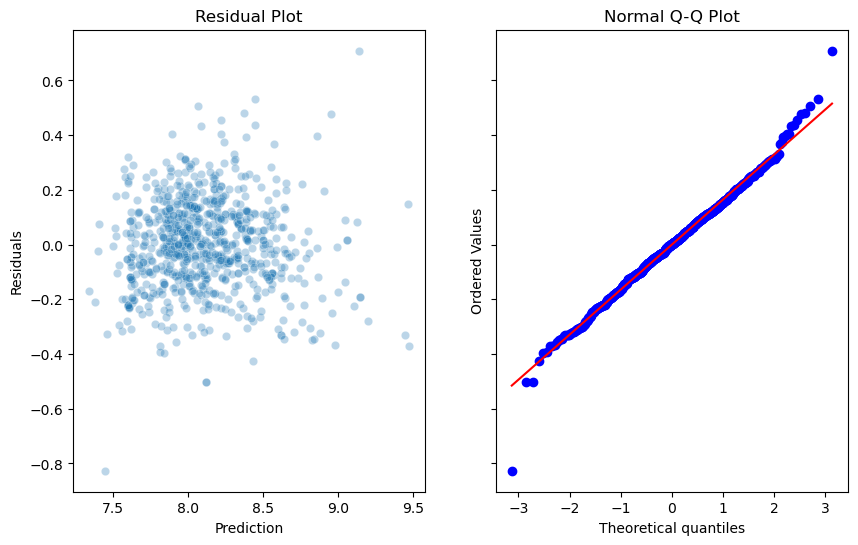

In [34]:
features = ['sqft', 'beds', 'bath', 'laundry_not_in_unit', 'parking_(b) protected','parking_(c) off-street', 'parking_(d) no parking', 'district_zone_fidi_soma', 'district_zone_marina','district_zone_north_beach', 'district_zone_southwest','district_zone_west']
m4 = cv_evaluate(X_train, y_train, features, 'M4_district')
print(m4.summary())
residual_analysis_plots(m4)

CV R2:  0.771 +- 0.036
CV MAE: 515.3 +- 46.8
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.781
Model:                            OLS   Adj. R-squared:                  0.779
Method:                 Least Squares   F-statistic:                     349.5
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          2.77e-252
Time:                        11:31:08   Log-Likelihood:                 247.71
No. Observations:                 791   AIC:                            -477.4
Df Residuals:                     782   BIC:                            -435.4
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

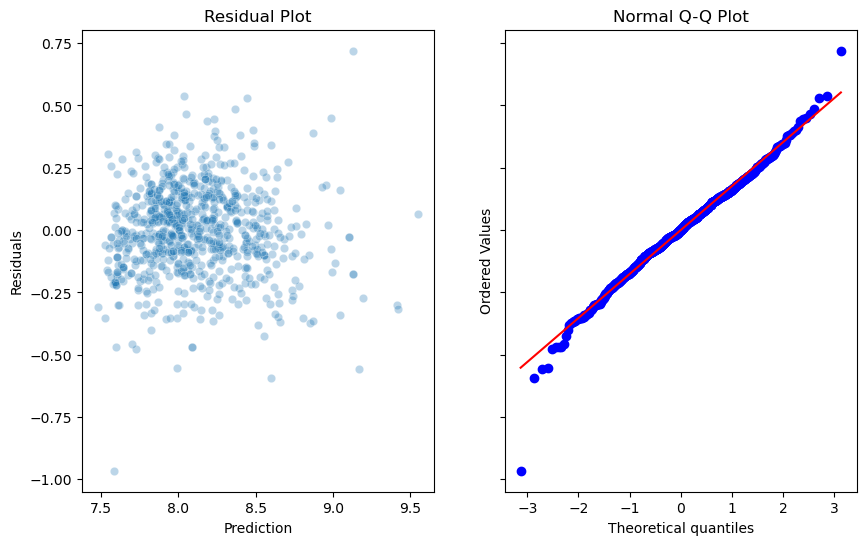

In [35]:
features = ['sqft', 'beds', 'bath', 'laundry_not_in_unit', 'parking_(b) protected','parking_(c) off-street', 'parking_(d) no parking', 'pets_no_dogs']
m5 = cv_evaluate(X_train, y_train, features, 'M5_pets')
print(m5.summary())
residual_analysis_plots(m5)

CV R2:  0.772 +- 0.036
CV MAE: 514.9 +- 41.8
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.783
Model:                            OLS   Adj. R-squared:                  0.781
Method:                 Least Squares   F-statistic:                     353.0
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          1.32e-253
Time:                        11:31:08   Log-Likelihood:                 250.80
No. Observations:                 791   AIC:                            -483.6
Df Residuals:                     782   BIC:                            -441.5
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

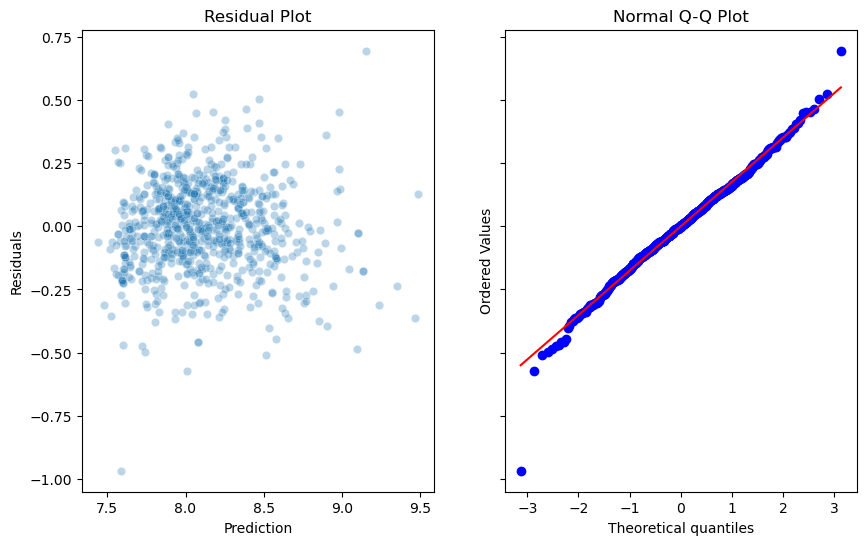

In [36]:
features = ['sqft', 'beds', 'bath', 'laundry_not_in_unit', 'parking_(b) protected','parking_(c) off-street', 'parking_(d) no parking', 'housing_type_single']
m6 = cv_evaluate(X_train, y_train, features, 'M6_housing_type')
print(m6.summary())
residual_analysis_plots(m6)

## Assumptions Checking

In [37]:
resutls_df = show_results()
resutls_df

,label,features,n_features,cv_r2_mean,cv_r2_std,cv_mae_mean,cv_mae_std
3,M4_district,"[sqft, beds, bath, laundry_not_in_unit, parkin...",12,0.798,0.030,490.3,45.3
2,M3_parking,"[sqft, beds, bath, laundry_not_in_unit, parkin...",7,0.770,0.035,513.5,45.8
5,M6_housing_type,"[sqft, beds, bath, laundry_not_in_unit, parkin...",8,0.772,0.036,514.9,41.8
4,M5_pets,"[sqft, beds, bath, laundry_not_in_unit, parkin...",8,0.771,0.036,515.3,46.8
1,M2_laundry,"[sqft, beds, bath, laundry_not_in_unit]",4,0.754,0.038,543.3,48.9
0,M1_baseline,"[sqft, beds, bath]",3,0.737,0.040,559.9,52.7


In [38]:
m4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.810
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     276.9
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          4.28e-271
Time:                        11:31:08   Log-Likelihood:                 303.62
No. Observations:                 791   AIC:                            -581.2
Df Residuals:                     778   BIC:                            -520.5
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         7.7707      0.044    176.443      0.000       7.684       7.857
sqft                          0.0004   2.32e-05     17.437      0.000       0.000       0.000
beds                          0.0996      0.009     11.072      0.000       0.082       0.117
bath                          0.0447      0.016      2.743      0.006       0.013       0.077
laundry_not_in_unit          -0.0735      0.014     -5.249      0.000      -0.101      -0.046
parking_(b) protected        -0.1714      0.035     -4.875      0.000      -0.240      -0.102
parking_(c) off-street       -0.1885      0.046     -4.105      0.000      -0.279      -0.098
parking_(d) no parking       -0.2549      0.036     -7.006      0.000      -0.326      -0.183
district_zone_fidi_soma      -0.0381      0.018     -2.111      0.035      -0.074      -0.003
district_zone_marina          0.0483      0.022      2.198      0.028       0.005       0.092
district_zone_north_beach    -0.0518      0.019     -2.713      0.007      -0.089      -0.014
district_zone_southwest      -0.2089      0.023     -8.988      0.000      -0.254      -0.163
district_zone_west           -0.1064      0.030     -3.511      0.000      -0.166      -0.047
==============================================================================
Omnibus:                       18.591   Durbin-Watson:                   1.991
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               37.563
Skew:                          -0.020   Prob(JB):                     6.97e-09
Kurtosis:                       4.067   Cond. No.                     1.36e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.36e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

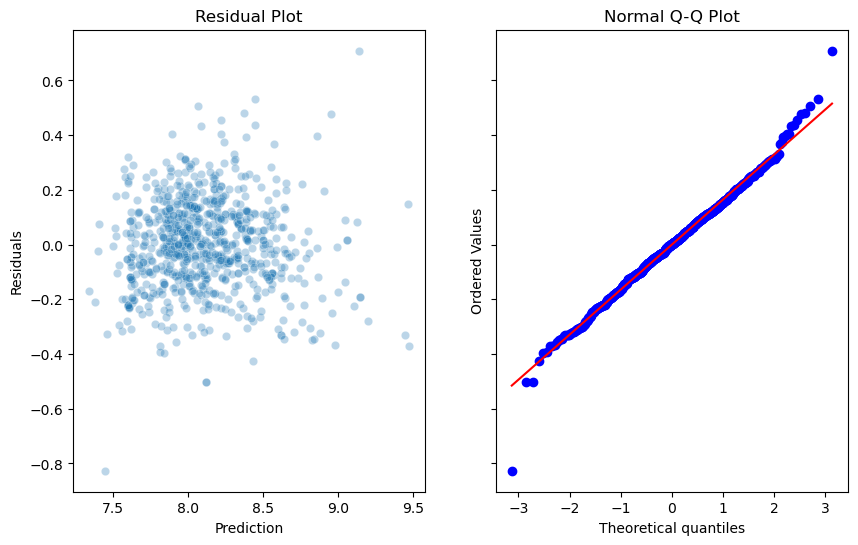

In [39]:
residual_analysis_plots(m4)

## Final Model Fit & Test Scoring

Test R2:  0.775
Test MAE: 511.8
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.810
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     276.9
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          4.28e-271
Time:                        11:31:08   Log-Likelihood:                 303.62
No. Observations:                 791   AIC:                            -581.2
Df Residuals:                     778   BIC:                            -520.5
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

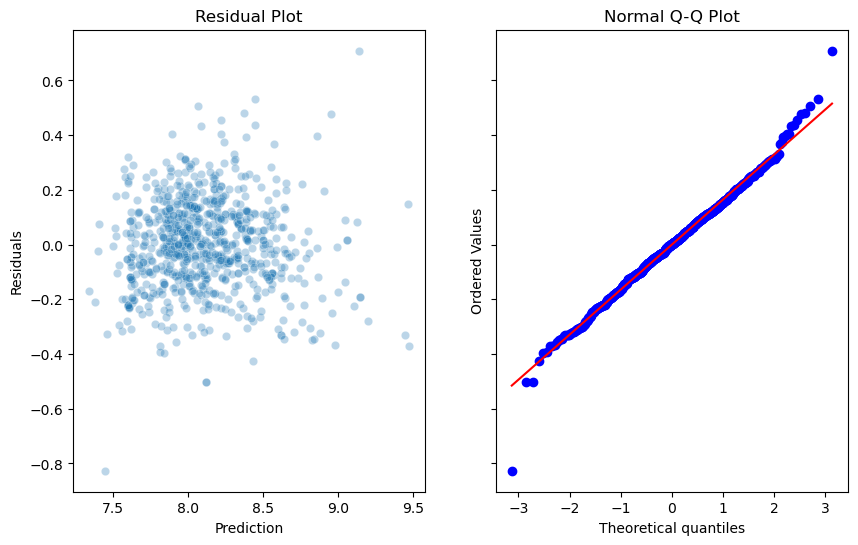

In [40]:
final_model = score_final_model(X_train, y_train, X_test, y_test, 'M4_district')
print(final_model.summary())
residual_analysis_plots(final_model)